In [1]:
# 1. Generate a lookup table from PAI signal to mvf.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import seaborn as sns
from paiskintonetools import setup_matplotlib  # type: ignore

from paiskintonetools.stats import loess_bootstrap  #  type:ignore

In [2]:
setup_matplotlib(100)


def agg_function(x, npf=np.nanmean):
    if np.issubdtype(x.dtype, np.number):
        return npf(x)
    elif hasattr(x.iloc[0], "dtype"):
        # Assume that this is a numpy array.
        return npf(np.stack(x), axis=0)
    else:
        return x.iloc[0]

In [3]:
def mvf_from_ita(ita):
    # From Else 2023 Journal of Biomedical Optics
    return (19.028 - 0.3692 * ita + 0.001685 * ita**2) / 100

In [4]:
df = pd.read_parquet("tables/pa_values_extracted_all_meta.parquet")
df = df.query("`ROI Name`=='skin' & `Fitzpatrick Type` != 'Vitiligo'")
df = df.groupby(["SkinID", "Region"]).agg(agg_function)
df["Sig700"] = df["spectrum_positive_mean"].apply(lambda x: x[0])
df["MVF"] = mvf_from_ita(df["ITA"])

In [5]:
df_ca = df.query("Region=='Carotid Artery'")

In [6]:
df_ca[df_ca["ITA"] < -30].index.get_level_values(0).unique().shape

(7,)

In [7]:
df["Fitzpatrick Type"].unique()

array(['2', '3', '4', '1', '5', '6'], dtype=object)

p =  5.12102682233336e-70
r2 =  0.8954047746793653


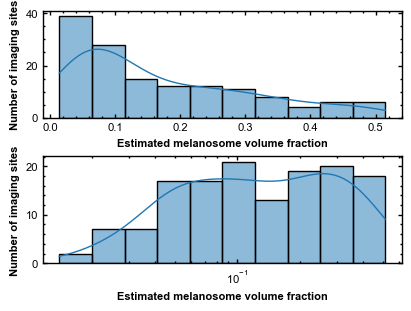

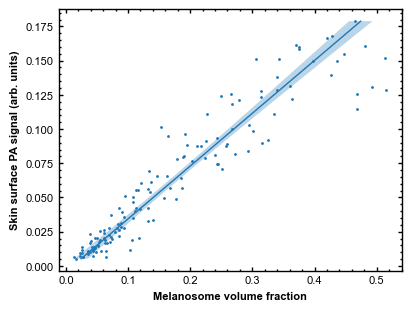

In [8]:
# Plot ITA vs 700 nm signal for all body parts.
# Then fit a line of best fit.
fig, (ax2, ax3) = plt.subplots(2, figsize=(4, 3))
fig2, ax = plt.subplots(figsize=(4, 3))
ax.scatter(df["MVF"], df["Sig700"], s=1)

linear_model = smf.ols("MVF ~ Sig700", data=df).fit()

print("p = ", linear_model.pvalues["Sig700"])
print("r2 = ", linear_model.rsquared)

xs_eval = np.linspace(np.min(df["Sig700"]), np.max(df["Sig700"]), 500)

pr = linear_model.get_prediction({"Sig700": xs_eval})
lower, upper = pr.conf_int().T

ax.plot(pr.predicted_mean, xs_eval)
ax.fill_betweenx(xs_eval, lower, upper, facecolor="C0", alpha=0.3)

ax.set_ylabel("Skin surface PA signal (arb. units)")
ax.set_xlabel("Melanosome volume fraction")
sns.histplot(df, x="MVF", ax=ax2, bins=10, kde=True)
ax2.set_ylabel("Number of imaging sites")
ax2.set_xlabel("Estimated melanosome volume fraction")
sns.histplot(df, x="MVF", ax=ax3, log_scale=True, bins=10, kde=True)
ax3.set_ylabel("Number of imaging sites")
ax3.set_xlabel("Estimated melanosome volume fraction")
plt.show()

In [9]:
# Calculate predicted MVFs for all:
df_export_skin_values = pd.read_parquet("tables/pa_values_extracted_all_meta.parquet")
df_export_skin_values = (
    df_export_skin_values.query("`ROI Name`=='skin'")
    .groupby("File")
    .agg(agg_function)
    .reset_index()
)
# df_export_skin_values["File"].apply(lambda x: Path(x).parent.stem + "/" + Path(x).stem)

df_export_skin_values["Sig700"] = df_export_skin_values["spectrum_positive_mean"].apply(
    lambda x: x[0]
)

df_export_skin_values["PADerivedMVFEstimate"] = linear_model.predict(
    df_export_skin_values
)

df_export_skin_values["ITADerivedMVFEstimate"] = mvf_from_ita(
    df_export_skin_values["ITA"]
)
df_export_skin_values["ScanNumber"] = df_export_skin_values["ScanNumber"].apply(int)

df_export_skin_values[
    ["SkinID", "ScanNumber", "PADerivedMVFEstimate", "ITADerivedMVFEstimate"]
].head(10)

,SkinID,ScanNumber,PADerivedMVFEstimate,ITADerivedMVFEstimate
0,SKIN01,10,0.026215,0.013914
1,SKIN01,11,0.024096,0.013914
2,SKIN01,12,0.025021,0.013914
3,SKIN01,13,0.055369,0.039680
4,SKIN01,14,0.061137,0.039680
5,SKIN01,15,0.069947,0.039680
6,SKIN01,16,0.081550,0.039680
7,SKIN01,17,0.033330,0.039680
8,SKIN01,18,0.037510,0.039680
9,SKIN01,19,0.036188,0.039680


In [10]:
df_export_skin_values[["SkinID", "ScanNumber", "PADerivedMVFEstimate"]].to_parquet(
    "tables/pa_derived_mvf_estimate.parquet"
)

In [11]:
# Make some plots of ITA against various other factors with log/no logs.

In [12]:
df.reset_index()[["ITA", "Sig700", "Region", "SkinID"]].to_csv(
    "../Analysis/plotted_data/figure_s1.csv"
)

In [13]:
df

Pigment Side     ITA  CIE-L*  CIE-a*  CIE-b*  Melanin  \
SkinID Region                                                                 
SKIN01 Bicep                        70.370  69.762   1.540   7.048   29.626   
       Carotid Artery               54.196  64.894   6.008  10.720   29.234   
       Leg                          61.702  64.848   2.532   7.972   34.588   
       Radial Artery                64.518  67.456   1.456   8.276   31.650   
SKIN02 Bicep                        56.256  64.468   2.892   9.660   33.822   
...                       ...  ...     ...     ...     ...     ...      ...   
SKIN42 Radial Artery               -19.218  43.540   9.488  18.542   53.160   
SKIN43 Bicep                       -13.662  45.290   9.072  19.484   51.670   
       Carotid Artery              -24.828  43.070  10.308  15.072   54.122   
       Leg                          -9.066  46.866   8.078  19.618   50.884   
       Radial Artery                -3.536  48.660   8.390  21.648   47.638   

                       Eryth.     sR     sG  ...  \
SkinID Region                                ...   
SKIN01 Bicep            6.252  192.6  165.0  ...   
       Carotid Artery  15.492  187.8  149.2  ...   
       Leg              9.366  180.2  151.4  ...   
       Radial Artery    7.700  186.4  159.2  ...   
SKIN02 Bicep           10.860  180.8  150.0  ...   
...                       ...    ...    ...  ...   
SKIN42 Radial Artery   27.328  135.2   93.6  ...   
SKIN43 Bicep           24.250  139.8   98.0  ...   
       Carotid Artery  28.340  134.2   92.0  ...   
       Leg             21.952  143.2  102.4  ...   
       Radial Artery   21.306  149.4  106.4  ...   

                       pacorrectionthb_positive_std pacorrectionso2_mean  \
SkinID Region                                                              
SKIN01 Bicep                               0.000004             0.358230   
       Carotid Artery                      0.000023             0.338941   
       Leg                                 0.000011             0.290017   
       Radial Artery                       0.000009             0.483850   
SKIN02 Bicep                               0.000004             0.307735   
...                                             ...                  ...   
SKIN42 Radial Artery                       0.000172             0.294973   
SKIN43 Bicep                               0.000086             0.257573   
       Carotid Artery                      0.000107             0.252955   
       Leg                                 0.000126             0.246903   
       Radial Artery                       0.000085             0.304945   

                       pacorrectionso2_median pacorrectionso2_std Age range  \
SkinID Region                                                                 
SKIN01 Bicep                         0.336483            0.199255     20-29   
       Carotid Artery                0.276446            0.245241     20-29   
       Leg                           0.231658            0.241260     20-29   
       Radial Artery                 0.452440            0.251467     20-29   
SKIN02 Bicep                         0.305727            0.175244     30-39   
...                                       ...                 ...       ...   
SKIN42 Radial Artery                 0.179259            0.319098     20-29   
SKIN43 Bicep                         0.163100            0.275585     30-39   
       Carotid Artery                0.140823            0.295801     30-39   
       Leg                           0.138675            0.289071     30-39   
       Radial Artery                 0.196800            0.311640     30-39   

                       Gender Fitzpatrick Type   BMI    Sig700       MVF  
SkinID Region                                                             
SKIN01 Bicep             Male                2  25.5  0.006664  0.013914  
       Carotid Artery    Male                2  25.5  0.022952  0.039680  


/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/PAISKINTONETools/paiskintonetools/paiskintonetools/stats.py:355: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_b = x[x_select]
/Users/telse/Documents/Code/CambridgeBits/PAISKINTONE/PAISKINTONETools/paiskintonetools/paiskintonetools/stats.py:356: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_b = y[x_select]


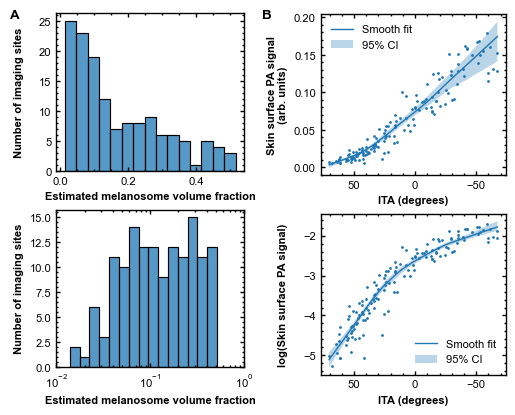

In [14]:
# Plot ITA vs 700 nm signal for all body parts.
# Then fit a line of best fit.
fig = plt.figure(figsize=(5, 4))
subfiga, subfigb = fig.subfigures(1, 2)
ax1, ax2 = subfiga.subplots(2)
ax3, ax4 = subfigb.subplots(2)
# ((ax1, ax2), (ax3, ax4))

sns.histplot(df, x="MVF", ax=ax1, bins=15)
ax1.set_ylabel("Number of imaging sites")
ax1.set_xlabel("Estimated melanosome volume fraction")
sns.histplot(df, x="MVF", ax=ax2, log_scale=True, bins=15)
ax2.set_ylabel("Number of imaging sites")
ax2.set_xlabel("Estimated melanosome volume fraction")

ax3.scatter(df["ITA"], df["Sig700"], s=1)
xs_eval, mean, upper, lower = loess_bootstrap(df["ITA"], df["Sig700"], frac=0.5)
ax3.plot(xs_eval, mean, label="Smooth fit")
ax3.fill_between(xs_eval, lower, upper, facecolor="C0", alpha=0.3, label="95% CI")
ax3.legend()
# Log version
ax4.scatter(df["ITA"], np.log(df["Sig700"]), s=1)
xs_eval, mean, upper, lower = loess_bootstrap(df["ITA"], np.log(df["Sig700"]), frac=0.5)
ax4.plot(xs_eval, mean, label="Smooth fit")
ax4.fill_between(xs_eval, lower, upper, facecolor="C0", alpha=0.3, label="95% CI")
ax4.legend()
# ax.set_ylabel("log(Skin surface PA signal)")
# ax.set_xlabel("ITA (degrees)")
ax3.invert_xaxis()
ax4.invert_xaxis()
ax3.set_xlabel("ITA (degrees)")
ax4.set_xlabel("ITA (degrees)")
ax3.set_ylabel("Skin surface PA signal\n(arb. units)")
ax4.set_ylabel("log(Skin surface PA signal)")
# fig.align_xlabels([ax1, ax2])
# fig.align_xlabels([ax3, ax4])
ax2.set_xlim([1e-2, 1])
subfiga.align_ylabels([ax1, ax2])
subfigb.align_ylabels([ax3, ax4])
subfiga.text(0, 1, "A", fontsize="large", fontweight="bold", va="top", ha="left")
subfigb.text(0, 1, "B", fontsize="large", fontweight="bold", va="top", ha="left")
fig.savefig("figures/mvfhistogram_logs.pdf", dpi=300)
plt.show()

Index(['Bicep', 'Carotid Artery', 'Leg', 'Radial Artery'], dtype='object', name='Region')


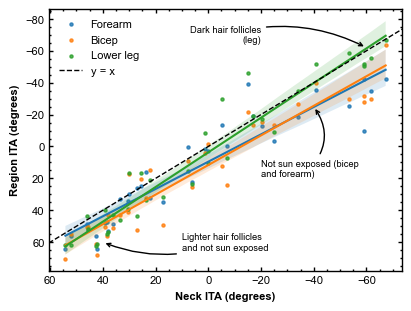

In [15]:
ita_all = (
    df[["ITA"]].reset_index().pivot(columns="Region", index="SkinID", values="ITA")
)

print(ita_all.columns)

fig, ax = plt.subplots(figsize=(4, 3))
sns.regplot(
    ita_all,
    x="Carotid Artery",
    y="Radial Artery",
    ax=ax,
    label="Forearm",
    scatter_kws=dict(s=5),
)
sns.regplot(
    ita_all, x="Carotid Artery", y="Bicep", ax=ax, label="Bicep", scatter_kws=dict(s=5)
)
sns.regplot(
    ita_all,
    x="Carotid Artery",
    y="Leg",
    ax=ax,
    label="Lower leg",
    scatter_kws=dict(s=5),
)
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel("Neck ITA (degrees)")
ax.set_ylabel("Region ITA (degrees)")

# Add a y=x line.
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Upper
upper = min(max(xlim), max(ylim))
lower = max(min(ylim), min(ylim))

ax.plot([lower, upper], [lower, upper], c="k", linestyle="--", label="y = x")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()

ax.annotate(
    "Dark hair follicles\n(leg)",
    (-60, -62),
    (-20, -70),
    ha="right",
    va="center",
    fontsize="small",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
)

ax.annotate(
    "Lighter hair follicles\nand not sun exposed",
    (40, 60),
    (10, 60),
    ha="left",
    va="center",
    fontsize="small",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2"),
)

ax.annotate(
    "Not sun exposed (bicep\nand forearm)",
    (-40, -25),
    (-20, 20),
    ha="left",
    va="bottom",
    fontsize="small",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.4"),
)
plt.savefig("figures/ita_regionvsregion.pdf", dpi=300)
plt.show()

In [16]:
from statsmodels.stats.multitest import multipletests

ps = []
for x in ["Radial Artery", "Bicep", "Leg"]:
    model = smf.ols(f"I(Q('Carotid Artery') - Q('{x}')) ~ Q('{x}')", ita_all).fit()
    # print(model.summary())
    print(model.params["Intercept"])
    ps.append(model.pvalues["Intercept"])
    ps.append(model.pvalues[f"Q('{x}')"])
    # if x == "Leg":
    #     print(model.summary())
test_results = multipletests(ps)
sig = test_results[0].reshape((3, 2))
p = test_results[1].reshape((3, 2))

for name, signif, pval in zip(["RA", "Bicep", "Leg"], sig, p):
    print(
        f"Name: {name}\nIntercept {signif[0]} {pval[0]:.3f}\nGradient {signif[1]} {pval[1]:.3f}"
    )

-9.038337033051448
-10.58871895629977
-2.7099232184595854
Name: RA
Intercept True 0.004
Gradient False 0.764
Name: Bicep
Intercept True 0.000
Gradient False 0.764
Name: Leg
Intercept False 0.370
Gradient True 0.005


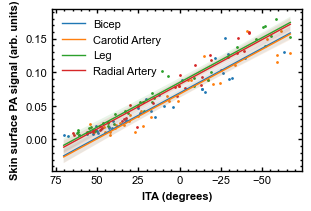

In [17]:
# Plot ITA vs 700 nm signal for all body parts.
# Then fit a line of best fit.
fig2, ax = plt.subplots(figsize=(3, 2), sharex=True)

regions = []
for n, g in df.groupby("Region"):
    ax.scatter(g["ITA"], g["Sig700"], s=1)
    regions.append(n)

# Tried Mixed effects not needed - not a large variance attributable to participant variable.
# test = smf.mixedlm(
#     "Sig700 ~ ITA + Region",
#     data=df.query("Parallel == ''").reset_index(),
#     groups="SkinID",
# )

linear_model = smf.ols(
    "Sig700 ~ ITA + Region",
    data=df.query("Parallel == '' & ITA < 40").reset_index(),
).fit()

xs_eval = np.linspace(np.min(df["ITA"]), np.max(df["ITA"]), 500)

for reg in regions:
    pr = linear_model.get_prediction(
        {
            "ITA": xs_eval,
            "Region": xs_eval.shape[0] * [reg],
        }
    )
    lower, upper = pr.conf_int().T

    lines = ax.plot(xs_eval, pr.predicted_mean, label=reg)
    ax.fill_between(xs_eval, lower, upper, facecolor=lines[0].get_color(), alpha=0.1)

# xs_eval, mean, upper, lower = loess_bootstrap(df["ITA"], np.log(df["Sig700"]), frac=0.5)
# ax.plot(xs_eval, mean)
# ax.fill_between(xs_eval, lower, upper, facecolor="C0", alpha=0.3)
ax.legend(loc="upper left")
ax.set_ylabel("Skin surface PA signal (arb. units)")
ax.set_xlabel("ITA (degrees)")
ax.invert_xaxis()

plt.show()

In [18]:
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Sig700   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     178.1
Date:                Tue, 19 May 2026   Prob (F-statistic):           1.07e-42
Time:                        12:04:34   Log-Likelihood:                 271.99
No. Observations:                  98   AIC:                            -534.0
Df Residuals:                      93   BIC:                            -521.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.0691      0.003     20.319      0.000       0.062       0.076
Region[T.Carotid Artery]    -0.0016      0.004     -0.363      0.717      -0.010       0.007
Region[T.Leg]                0.0157      0.005      3.365      0.001       0.006       0.025
Region[T.Radial Artery]      0.0129      0.005      2.818      0.006       0.004       0.022
ITA                         -0.0013   5.16e-05    -25.748      0.000      -0.001      -0.001
==============================================================================
Omnibus:                        3.503   Durbin-Watson:                   1.402
Prob(Omnibus):                  0.173   Jarque-Bera (JB):                3.029
Skew:                           0.425   Prob(JB):                        0.220
Kurtosis:                       3.138   Cond. No.                         145.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [19]:
linear_model.t_test_pairwise("Region").result_frame

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
Carotid Artery-Bicep,-0.001612,0.004441,-0.362932,0.717480,-0.010432,0.007208,0.783808,False
Leg-Bicep,0.015748,0.004680,3.365288,0.001113,0.006455,0.025041,0.004443,True
Radial Artery-Bicep,0.012941,0.004592,2.818048,0.005902,0.003822,0.022061,0.017603,True
Leg-Carotid Artery,0.017360,0.004349,3.991683,0.000131,0.008724,0.025996,0.000785,True
Radial Artery-Carotid Artery,0.014553,0.004226,3.443999,0.000861,0.006162,0.022945,0.004299,True
Radial Artery-Leg,-0.002807,0.004508,-0.622654,0.535035,-0.011758,0.006144,0.783808,False
